# 👩‍💻 Build a Basic RNN to Model Sequential Patterns

## 📋 Overview
In this lab, you will build a Recurrent Neural Network (RNN) from scratch using PyTorch to model and predict character sequences. RNNs are powerful neural network architectures designed specifically for sequential data, maintaining a form of "memory" that allows them to learn patterns over time. You'll create a model that can recognize and predict the next character in repeating patterns, similar to how predictive text works in real-world applications.

In [1]:
# Starter code imports
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

## Task 1: Prepare Synthetic Sequential Data
**Context:** In real-world applications like text prediction or DNA sequence analysis, we need to convert character sequences into numerical representations that neural networks can process.

**Steps:**

1. Generate a simple repeating character sequence to serve as your dataset

In [2]:
# Create a repeating sequence

# Example pattern: "ABCABCABCABC"
sequence = "ABC" * 4  # Adjust multiplier to change length
print("Sequence:", sequence)

Sequence: ABCABCABCABC


2. Create mappings between characters and indices

In [3]:
# Create character to index and index to character mappings

chars = sorted(list(set(sequence)))  # unique characters, sorted for consistency
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

print("char2idx:", char2idx)
print("idx2char:", idx2char)

char2idx: {'A': 0, 'B': 1, 'C': 2}
idx2char: {0: 'A', 1: 'B', 2: 'C'}


3. Convert your sequence into numerical format

In [4]:
# Convert characters to indices

indices = [char2idx[ch] for ch in sequence]
indices_tensor = torch.tensor(indices, dtype=torch.long)

4. Create input and target tensors by offsetting the sequence by one position

In [5]:
# Create input tensor (all but last character) and target tensor (all but first character)


x_seq = indices_tensor[:-1]  # current step
y_seq = indices_tensor[1:]   # next-step prediction target

## Task 2: Build the RNN Model
**Context:** RNNs are used in many industries for sequence modeling, from voice assistants predicting your next word to financial systems forecasting stock prices.

**Steps:**

1. Define a basic RNN class using PyTorch's nn.Module

In [6]:
# Create an RNN class inheriting from nn.Module


class CharRNN(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int, num_layers: int = 1, dropout: float = 0.0):
        """
        Args:
            input_size: feature size of each time step (for our simple index-as-feature setup, this is 1)
            hidden_size: number of features in the RNN hidden state
            output_size: size of the vocabulary (number of unique characters)
            num_layers: number of stacked RNN layers
            dropout: dropout applied between RNN layers (ignored if num_layers=1)
        """
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Recurrent layer
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,   # => input/output as [batch, seq, feat]
            dropout=dropout if num_layers > 1 else 0.0,
            nonlinearity="tanh" # default; could switch to 'relu'
        )

        # Output projection: hidden -> logits over characters
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        """
        Args:
            x: input tensor of shape [batch, seq_len, input_size]
            h0: optional initial hidden state of shape [num_layers, batch, hidden_size]
        Returns:
            logits: [batch, seq_len, output_size]
            hn:     [num_layers, batch, hidden_size] (final hidden state)
        """
        # RNN forward
        out, hn = self.rnn(x, h0)  # out: [batch, seq_len, hidden_size]

        # Map each hidden state to vocab logits
        logits = self.fc(out)      # [batch, seq_len, output_size]
        return logits, hn

    def init_hidden(self, batch_size: int, device=None):
        """
        Initialize hidden state to zeros.
        Returns shape [num_layers, batch_size, hidden_size].
        """
        device = device if device is not None else next(self.parameters()).device
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

2. Implement the constructor with appropriate layers
    - Use nn.RNN for the recurrent layer
    - Use nn.Linear for the output layer

In [7]:
# Initialize the RNN and Linear layers

if "x" not in globals():
    sequence = "ABC" * 4
    chars = sorted(list(set(sequence)))
    char2idx = {ch: i for i, ch in enumerate(chars)}
    indices = [char2idx[ch] for ch in sequence]
    indices_tensor = torch.tensor(indices, dtype=torch.long)
    x_seq = indices_tensor[:-1]
    x = x_seq.unsqueeze(0).unsqueeze(-1)  # [1, seq_len-1, 1]

vocab_size = len(char2idx)
input_size = 1            # we are passing index as a single feature
hidden_size = 16          # hyperparameter; feel free to tune
output_size = vocab_size  # logits over characters

model = CharRNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
print(model)

CharRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=3, bias=True)
)


3. Implement the forward method to process sequences. The nn.RNN layer expects input shape [batch, sequence, input_size] (with batch_first=True) and outputs [batch, sequence, hidden_size]. The nn.Linear layer maps the hidden state to the output size (number of unique characters).

In [8]:
# Define the forward pass


with torch.no_grad():
    batch_size = x.size(0)
    h0 = model.init_hidden(batch_size=batch_size)              # [num_layers, batch, hidden]
    logits, hn = model(x.float(), h0)                          # Cast x to float to match expected dtype

print("logits shape:", logits.shape)  # Expected: [1, seq_len-1, vocab_size]
print("hn shape:", hn.shape)          # Expected: [num_layers, 1, hidden_size]

# Optionally, convert logits to predicted indices (greedy) for a peek:
pred_indices = logits.argmax(dim=-1)  # [1, seq_len-1]
print("Pred indices (first 10):", pred_indices[0, :10].tolist())

logits shape: torch.Size([1, 11, 3])
hn shape: torch.Size([1, 1, 16])
Pred indices (first 10): [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]


4. Add a helper method to initialize the hidden state

In [9]:
# Add a method to initialize the hidden state

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0):
        out, hn = self.rnn(x, h0)
        logits = self.fc(out)
        return logits, hn

    # -------------------------------------------
    # Hidden state initializer (zeros)
    # -------------------------------------------
    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

5. Initialize your model with appropriate dimensions

In [10]:
# Initialize model with input_size, hidden_size, and output_size

input_size  = 1
hidden_size = 16
output_size = len(char2idx)   # created earlier in Task 1

model = CharRNN(input_size, hidden_size, output_size)

print(model)

CharRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=3, bias=True)
)


## Task 3: Train the RNN
**Context:** Training sequential models requires handling both the sequence data and evolving hidden states across time steps.

**Steps:**

1. Define your loss function and optimizer

In [11]:
# Set up loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)  # tune lr if needed

In [12]:
# ---------------------------------------------------
# Ensure x, y, and char2idx exist (recreate if needed)
# ---------------------------------------------------
if "x" not in globals() or "y" not in globals() or "char2idx" not in globals():
    sequence = "ABC" * 4
    chars = sorted(list(set(sequence)))
    char2idx = {ch: i for i, ch in enumerate(chars)}
    idx2char = {i: ch for ch, i in char2idx.items()}

    indices = [char2idx[ch] for ch in sequence]
    indices_tensor = torch.tensor(indices, dtype=torch.long)

    # Build input/target sequences
    x_seq = indices_tensor[:-1]             # input indices
    y_seq = indices_tensor[1:]              # target indices

    x = x_seq.unsqueeze(0).unsqueeze(-1)    # [1, T, 1]
    y = y_seq.unsqueeze(0)                  # [1, T]

2. Create a training loop

In [14]:
# Create a loop for training iterations

epochs = 400
loss_history = []

model.train()
batch_size = x.size(0)
h = model.init_hidden(batch_size=batch_size)  # carry hidden state across iterations

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # Detach hidden to avoid backprop through entire history (truncated BPTT)
    h = h.detach()

    # Forward pass
    logits, h = model(x.float(), h)  # logits: [B, T, V]

    # Compute loss
    # CrossEntropyLoss expects [N, C] and targets [N]
    B, T, V = logits.shape
    loss = criterion(logits.reshape(B * T, V), y.reshape(B * T).long())

    # Backward + optimize
    loss.backward()
    # Optional: gradient clipping to prevent exploding gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()

    # Store & log
    loss_history.append(loss.item())
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} | Loss: {loss.item():.4f}")

Epoch   1/400 | Loss: 1.1679
Epoch  50/400 | Loss: 0.0010
Epoch 100/400 | Loss: 0.0003
Epoch 150/400 | Loss: 0.0002
Epoch 200/400 | Loss: 0.0001
Epoch 250/400 | Loss: 0.0001
Epoch 300/400 | Loss: 0.0001
Epoch 350/400 | Loss: 0.0001
Epoch 400/400 | Loss: 0.0001


In [15]:
print("x shape:", x.shape)
print("y shape:", y.shape)
print("vocab size:", len(char2idx))

x shape: torch.Size([1, 11, 1])
y shape: torch.Size([1, 11])
vocab size: 3


3. Inside the loop, initialize the hidden state for each sequence

In [16]:
# Initialize hidden state

input_size  = 1
hidden_size = 16
output_size = len(char2idx)   # created earlier in Task 1

model = CharRNN(input_size, hidden_size, output_size)

print(model)

CharRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=3, bias=True)
)


4. Forward pass: get predictions from the model

In [17]:
# Forward pass
logits, h = model(x.float(), h)

5. Calculate loss between predictions and targets

In [18]:
# Calculate loss

# Calculate loss
B, T, V = logits.shape
loss = criterion(logits.reshape(B * T, V), y.reshape(B * T).long())

In [22]:
loss = criterion(logits.reshape(B*T, V), y.reshape(B*T).long())

6. Perform backpropagation and update weights

In [25]:

for epoch in range(epochs):

    # Correct: detach BEFORE forward
    h = h.detach()

    logits, h = model(x.float(), h)

    B, T, V = logits.shape
    loss = criterion(logits.reshape(B*T, V), y.reshape(B*T).long())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

In [26]:
h = model.init_hidden(batch_size=1)

7. Track and store loss values for visualization

In [29]:
# Store loss values
# Store loss values
loss_history.append(loss.item())

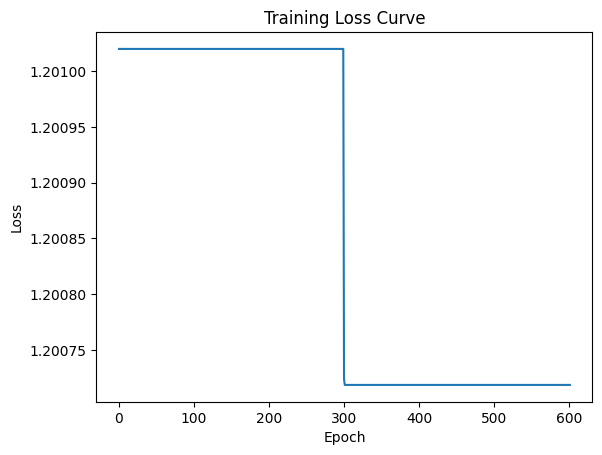

In [30]:

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## Task 4: Evaluate and Visualize Results
**Context:** Visualization helps us understand the model's learning progress and performance on sequence prediction tasks.

**Steps:**

1. Prepare the model for evaluation mode

In [31]:
# Set model to evaluation mode
model.eval()

CharRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=3, bias=True)
)

2. Generate predictions for a test sequence

In [32]:
# Generate predictions

with torch.no_grad():
    h_eval = model.init_hidden(batch_size=1)
    logits_eval, h_seq = model(x.float(), h_eval)  # logits: [1, T, V]
    pred_indices = logits_eval.argmax(dim=-1)[0]   # shape: [T]

3. Convert numerical predictions back to characters

In [33]:
# Convert predictions to characters

predicted_chars = [idx2char[int(i)] for i in pred_indices]
true_chars =     [idx2char[int(j)] for j in y[0]]

In [34]:

print("Original sequence:", "".join(true_chars))
print("Predicted sequence:", "".join(predicted_chars))

Original sequence: BCABCABCABC
Predicted sequence: BBBBBBBBBBB


4. Visualize the original sequence vs predicted sequence

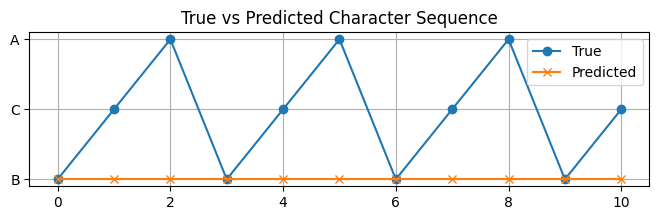

In [35]:
# Visualize results

plt.figure(figsize=(8, 2))
plt.plot(true_chars, label="True", marker='o')
plt.plot(predicted_chars, label="Predicted", marker='x')
plt.title("True vs Predicted Character Sequence")
plt.legend()
plt.grid(True)
plt.show()

5. Create a visualization of the hidden state evolution over time

In [36]:
# Visualize hidden state changes

hidden_states = []

with torch.no_grad():
    h = model.init_hidden(batch_size=1)
    for t in range(x.size(1)):
        xt = x[:, t:t+1, :].float()    # one timestep: [1, 1, 1]
        out, h = model.rnn(xt, h)
        hidden_states.append(h.squeeze(0).squeeze(0).numpy())  # shape: hidden_size

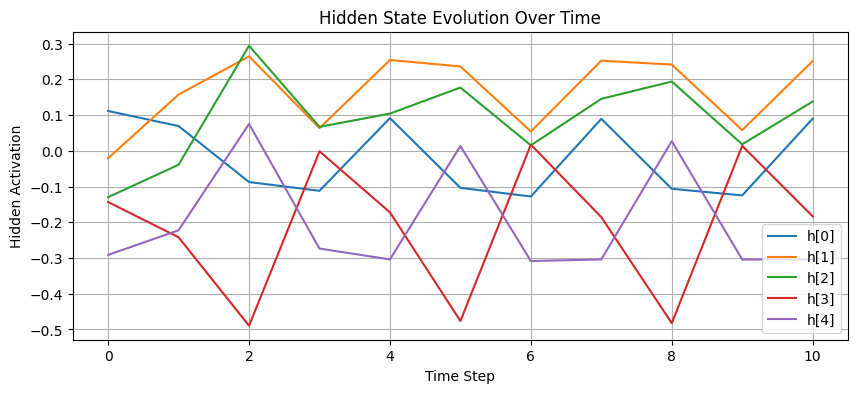

In [38]:

hidden_states = np.array(hidden_states)    # now has .shape (T, H)

# 3) Plot the first few hidden units over time
plt.figure(figsize=(10, 4))
num_dims_to_plot = min(5, hidden_states.shape[1])
for i in range(num_dims_to_plot):
    plt.plot(hidden_states[:, i], label=f"h[{i}]")
plt.title("Hidden State Evolution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden Activation")
plt.legend()
plt.grid(True)
plt.show()